Classificação de Dígitos Manuscritos com Machine Learning

Objetivo

Etapas de Desenvolvimento

1. Carregamento e Análise Exploratória dos Dados — EDA

1.1 Carregamento do Dataset MNIST

1.2 Formato dos Dados

1.3 Classes dos Dígitos

1.4 Quantidade de Amostras

1.5 Balanceamento das Classes

1.6 Visualização dos Dígitos

1.7 Análise dos Valores dos Pixels

1.8 Conclusão da Análise Exploratória

2. Preparação dos Dados

2.1 Separação em Treino, Validação e Teste

2.2 Estratificação das Classes

2.3 Normalização dos Pixels

2.4 Preparação dos Dados para os Modelos

3. Treinamento dos Modelos

3.1 Random Forest

3.2 KNN

3.3 SVM

3.4 Rede Neural MLP

3.5 Rede Neural Keras

3.6 Ajuste de Hiperparâmetros

4. Avaliação dos Modelos

4.1 Acurácia

4.2 Precisão

4.3 Recall

4.4 F1-Score

4.5 Matriz de Confusão

4.6 Tempo de Treinamento

4.7 Comparação dos Modelos

5. Teste de Robustez

5.1 Dígitos Ausentes no Treinamento

5.2 Teste com Imagens Externas

5.3 Processamento das Imagens com OpenCV

5.4 Avaliação da Generalização

6. Seleção do Modelo Final

6.1 Desempenho Preditivo

6.2 Custo Computacional

6.3 Robustez

6.4 Modelo Selecionado

Conclusão do Projeto


In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # pyright: ignore[reportMissingImports]
    from google.colab import drive  # pyright: ignore[reportMissingImports]
    IN_COLAB = True
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Modulo-02-MniProjeto
except ModuleNotFoundError:
    IN_COLAB = False
    print("Ambiente local detectado. Usando o diretório atual do projeto.")
    print(f"Diretório atual: {Path.cwd()}")

try:
    from IPython.display import display
except ImportError:
    def display(*args, **kwargs):
        for item in args:
            print(item)

Ambiente local detectado. Usando o diretório atual do projeto.
Diretório atual: c:\Modulo-02-MniProjeto


In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Dataset baixado com sucesso!

=== DIMENSIONALIDADE DOS MATRIZES ===
Matriz de Características (X): (70000, 784) (Imagens x Pixels)
Matriz de Rótulos (y): (70000,)



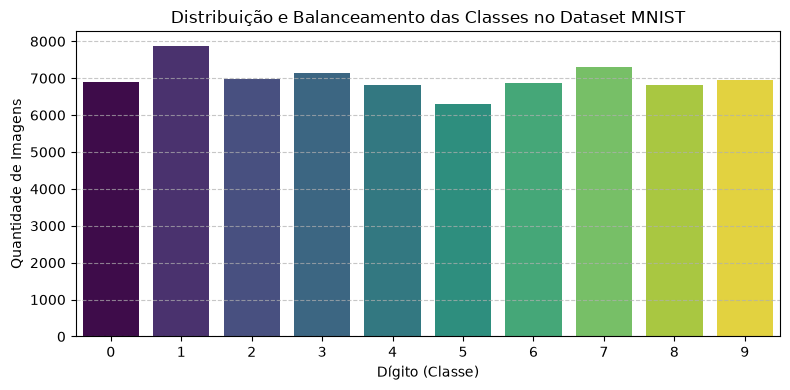

=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===


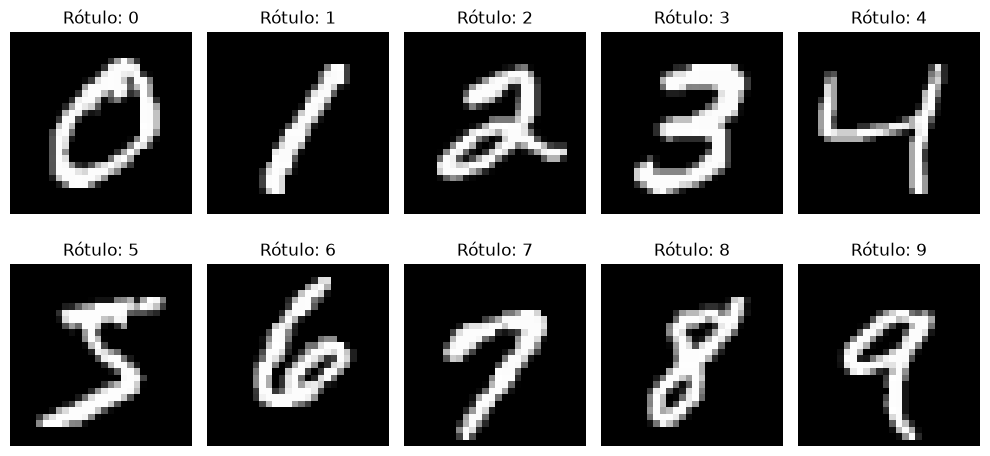

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import tensorflow as tf  # pyright: ignore[reportMissingModuleSource]
from tensorflow import keras  # pyright: ignore[reportMissingModuleSource]


pasta_graficos = Path('outputs') / 'graficos'
pasta_graficos.mkdir(parents=True, exist_ok=True)

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto',
    data_home='./data'
 )

print("Dataset baixado com sucesso!")

# Separando recursos (X) e rÃ³tulos (y)
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

# 1. EXIBIR DIMENSIONALIDADE
print("\n=== DIMENSIONALIDADE DOS MATRIZES ===")
print(f"Matriz de Características (X): {X.shape} (Imagens x Pixels)")
print(f"Matriz de Rótulos (y): {y.shape}\n")

# 2. COMPROVAR O BALANCEAMENTO DAS CLASSES
classes, contagens = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(
    x=classes,
    y=contagens,
    hue=classes,
    palette="viridis",
    legend=False
)
plt.title("Distribuição e Balanceamento das Classes no Dataset MNIST")
plt.xlabel("D­ígito (Classe)")
plt.ylabel("Quantidade de Imagens")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(pasta_graficos / '1 = distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. GERAR GRADE VISUAL (Mínimo 2x5)
print("=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    indice = np.where(y == i)
    imagem_digito = X[indice][0].reshape(28, 28)
    axes[i].imshow(imagem_digito, cmap="gray")
    axes[i].set_title(f"Rótulo: {i}", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(pasta_graficos / '2 = exemplos_digitos.png', dpi=300, bbox_inches='tight')
plt.show()

Fase 2: Preparação dos Dados

A normalização dos pixels para a escala [0, 1] é fundamental para algoritmos de Machine Learning, porque garante que todos os recursos (features) tenham o mesmo peso inicial. Para modelos lineares e baseados em distância métrica, dados não normalizados causam instabilidade no gradiente, fazendo com que o modelo demore muito mais para convergir (encontrar o resultado ideal) ou até mesmo falhe em convergir.

In [4]:
# Normalizando os valores dos pixels para o intervalo [0, 1]
x_scaled = X / 255.0  

X_train_val, X_test, y_train_val, y_test = train_test_split(
    x_scaled, 
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

display("\n=== DIVISÃO DO DATASET ===")
display(f"Treinamento: {X_train.shape[0]} amostras")
display(f"Validação: {X_val.shape[0]} amostras")
display(f"Teste: {X_test.shape[0]} amostras")

'\n=== DIVISÃO DO DATASET ==='

'Treinamento: 49000 amostras'

'Validação: 7000 amostras'

'Teste: 14000 amostras'

Fase 3: Treinamento dos Modelos

Nesta fase, treinamos modelos diferentes para descobrir qual deles reconhece melhor os dígitos. Cada modelo aprende de uma forma: a Random Forest usa várias árvores de decisão, o KNN procura imagens parecidas, o SVM separa as classes, a MLP aprende padrões por meio de neurônios artificiais e a rede Keras também usa camadas neurais profundas para aprender características cada vez mais abstratas.

1 = MODELO RANDOM FOREST

Foram usados `n_estimators=100` para combinar 100 árvores e reduzir a variação das previsões, e `max_depth=10` para limitar a complexidade e o tempo de treinamento.

In [5]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

tempo_inicio_rf = time.perf_counter()
modelo_rf.fit(X_train, y_train)
tempo_treinamento_rf = time.perf_counter() - tempo_inicio_rf

predicoes_rf = modelo_rf.predict(X_test)

report_dict = classification_report(y_test, predicoes_rf, output_dict=True)

df_metrics = pd.DataFrame(report_dict).transpose()

df_metrics.round(4)

,precision,recall,f1-score,support
0,0.9624,0.9833,0.9728,1381.0000
1,0.9643,0.9771,0.9707,1575.0000
2,0.9479,0.9363,0.9421,1398.0000
3,0.9385,0.9300,0.9342,1428.0000
4,0.9528,0.9326,0.9426,1365.0000
5,0.9579,0.9192,0.9382,1263.0000
6,0.9557,0.9731,0.9643,1375.0000
7,0.9488,0.9404,0.9446,1459.0000
8,0.9251,0.9231,0.9241,1365.0000
9,0.8904,0.9224,0.9061,1391.0000


2 = MODELO KNN

O KNN usa `n_neighbors=5`, equilibrando sensibilidade ao ruído e decisão local, e `weights='distance'`, dando maior importância aos vizinhos mais próximos.

In [6]:
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

tempo_inicio_knn = time.perf_counter()
modelo_knn.fit(X_train, y_train)
tempo_treinamento_knn = time.perf_counter() - tempo_inicio_knn

predicoes_knn = modelo_knn.predict(X_test)

report_dict_knn = classification_report(y_test, predicoes_knn, output_dict=True)

df_metrics_knn = pd.DataFrame(report_dict_knn).transpose()

df_metrics_knn.round(4)

,precision,recall,f1-score,support
0,0.9745,0.9949,0.9846,1381.0000
1,0.9543,0.9937,0.9736,1575.0000
2,0.9889,0.9528,0.9705,1398.0000
3,0.9706,0.9727,0.9717,1428.0000
4,0.9864,0.9568,0.9714,1365.0000
5,0.9613,0.9628,0.9620,1263.0000
6,0.9741,0.9862,0.9801,1375.0000
7,0.9634,0.9753,0.9693,1459.0000
8,0.9869,0.9377,0.9617,1365.0000
9,0.9485,0.9662,0.9573,1391.0000


3 = MODELO SVM

O kernel `rbf` permite fronteiras não lineares; `C=1.0` equilibra margem e erros de treino; e `gamma='scale'` ajusta a influência de cada amostra à escala dos dados.

### Perfil de execução: local ou Colab

Use `AMBIENTE = "local"` para desenvolver no computador e `AMBIENTE = "colab"` para a execução final completa. O SVM RBF cresce muito em custo com o número de imagens. No perfil local, ele treina uma amostra estratificada de 25 mil imagens; no Colab, usa todo o conjunto de treino. O teste permanece idêntico nos dois perfis, mas a comparação de tempo deve registrar sempre qual perfil foi utilizado.

In [7]:
# Detecta automaticamente o ambiente e escolhe o perfil mais seguro.
if 'IN_COLAB' not in globals():
    IN_COLAB = False

AMBIENTE = 'colab' if IN_COLAB else 'local'
AMOSTRAS_SVM_LOCAL = 25_000

if AMBIENTE not in {"local", "colab"}:
    raise ValueError("AMBIENTE deve ser 'local' ou 'colab'.")

if AMBIENTE == "local":
    X_train_svm, _, y_train_svm, _ = train_test_split(
        X_train, y_train, train_size=AMOSTRAS_SVM_LOCAL,
        stratify=y_train, random_state=42
    )
    print(f"Perfil local: SVM treinado com {len(y_train_svm):,} amostras.")
else:
    X_train_svm, y_train_svm = X_train, y_train
    print(f"Perfil Colab: SVM treinado com {len(y_train_svm):,} amostras.")


Perfil local: SVM treinado com 25,000 amostras.


In [8]:
modelo_svm = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    # probability=True executa uma calibraÃ§Ã£o interna cara. Use-a sÃ³ no resultado final.
    probability=(AMBIENTE == "colab"),
    cache_size=2048,
    random_state=42
)

tempo_inicio_svm = time.perf_counter()
modelo_svm.fit(X_train_svm, y_train_svm)
tempo_treinamento_svm = time.perf_counter() - tempo_inicio_svm

predicoes_svm = modelo_svm.predict(X_test)

report_dict_svm = classification_report(y_test, predicoes_svm, output_dict=True)
df_metrics_svm = pd.DataFrame(report_dict_svm).transpose()

print(f"Perfil usado no SVM: {AMBIENTE}")
df_metrics_svm.round(4)


c:\Modulo-02-MniProjeto\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Perfil usado no SVM: local


,precision,recall,f1-score,support
0,0.9751,0.9935,0.9842,1381.0000
1,0.9817,0.9873,0.9845,1575.0000
2,0.9658,0.9707,0.9682,1398.0000
3,0.9666,0.9538,0.9602,1428.0000
4,0.9692,0.9685,0.9689,1365.0000
5,0.9743,0.9612,0.9677,1263.0000
6,0.9741,0.9847,0.9794,1375.0000
7,0.9666,0.9733,0.9699,1459.0000
8,0.9654,0.9604,0.9629,1365.0000
9,0.9613,0.9454,0.9532,1391.0000


4 = REDE NEURAL PERCEPTRON

A MLP possui uma camada oculta com 100 neurônios e ativação ReLU para aprender padrões não lineares. O otimizador Adam e `max_iter=100` oferecem uma convergência eficiente com limite de iterações.

In [9]:
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

tempo_inicio_mlp = time.perf_counter()
modelo_mlp.fit(X_train, y_train)
tempo_treinamento_mlp = time.perf_counter() - tempo_inicio_mlp

predicoes_mlp = modelo_mlp.predict(X_test)

report_dict_mlp = classification_report(y_test, predicoes_mlp, output_dict=True)

df_metrics_mlp = pd.DataFrame(report_dict_mlp).transpose()

df_metrics_mlp.round(4)

,precision,recall,f1-score,support
0,0.9779,0.9949,0.9864,1381.0000
1,0.9836,0.9892,0.9864,1575.0000
2,0.9806,0.9764,0.9785,1398.0000
3,0.9781,0.9713,0.9747,1428.0000
4,0.9744,0.9744,0.9744,1365.0000
5,0.9730,0.9715,0.9723,1263.0000
6,0.9891,0.9855,0.9872,1375.0000
7,0.9714,0.9760,0.9737,1459.0000
8,0.9777,0.9641,0.9709,1365.0000
9,0.9627,0.9641,0.9634,1391.0000


## 5 = REDE NEURAL COM KERAS

A quinta etapa usa uma rede neural profunda em TensorFlow/Keras para comparar com a MLP do scikit-learn. A arquitetura foi escolhida para manter a mesma ideia da MLP anterior: entrada com 784 pixels, camadas densas com ReLU e saída com 10 classes, correspondendo aos dígitos de 0 a 9. A diferença principal é que a implementação em Keras permite treinar a rede com maior controle de otimização, batch e validação durante o treinamento.

Com o mesmo conjunto de treino e teste dos modelos anteriores, essa comparação ajuda a responder qual abordagem oferece o melhor equilíbrio entre desempenho e custo computacional.

In [10]:
try:
    import tensorflow as tf  # pyright: ignore[reportMissingModuleSource]
    from tensorflow import keras  # pyright: ignore[reportMissingModuleSource]
    print('TensorFlow já disponívél:', tf.__version__)
except ModuleNotFoundError:
    import subprocess, sys
    print('TensorFlow não encontrado. Instalando no ambiente do projeto...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow-cpu==2.16.2'])
    import tensorflow as tf  # pyright: ignore[reportMissingModuleSource]
    from tensorflow import keras  # pyright: ignore[reportMissingModuleSource]
    print('TensorFlow instalado com sucesso:', tf.__version__)


TensorFlow já disponívél: 2.21.0


Fase 4: Avaliação dos Modelos

Nesta fase, comparamos os resultados dos modelos usando dados de teste, que não foram usados no treinamento. A acurácia mostra a quantidade total de acertos; precisão, recall e F1-score ajudam a entender a qualidade das previsões em cada classe. As matrizes de confusão mostram quais dígitos o modelo mais confunde.

In [11]:
modelo_keras = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

modelo_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tempo_inicio_keras = time.perf_counter()
hist_keras = modelo_keras.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=0
)
tempo_treinamento_keras = time.perf_counter() - tempo_inicio_keras

predicoes_keras = modelo_keras.predict(X_test, verbose=0)
predicoes_keras = predicoes_keras.argmax(axis=1)

report_dict_keras = classification_report(y_test, predicoes_keras, output_dict=True)
df_metrics_keras = pd.DataFrame(report_dict_keras).transpose()

print(f"Rede Keras treinada com {X_train.shape[0]} amostras no mesmo split dos outros modelos.")
df_metrics_keras.round(4)

Rede Keras treinada com 49000 amostras no mesmo split dos outros modelos.


,precision,recall,f1-score,support
0,0.9835,0.9920,0.9877,1381.0000
1,0.9769,0.9917,0.9842,1575.0000
2,0.9770,0.9742,0.9756,1398.0000
3,0.9851,0.9713,0.9781,1428.0000
4,0.9777,0.9626,0.9701,1365.0000
5,0.9777,0.9739,0.9758,1263.0000
6,0.9811,0.9840,0.9826,1375.0000
7,0.9799,0.9712,0.9756,1459.0000
8,0.9666,0.9758,0.9712,1365.0000
9,0.9600,0.9669,0.9635,1391.0000


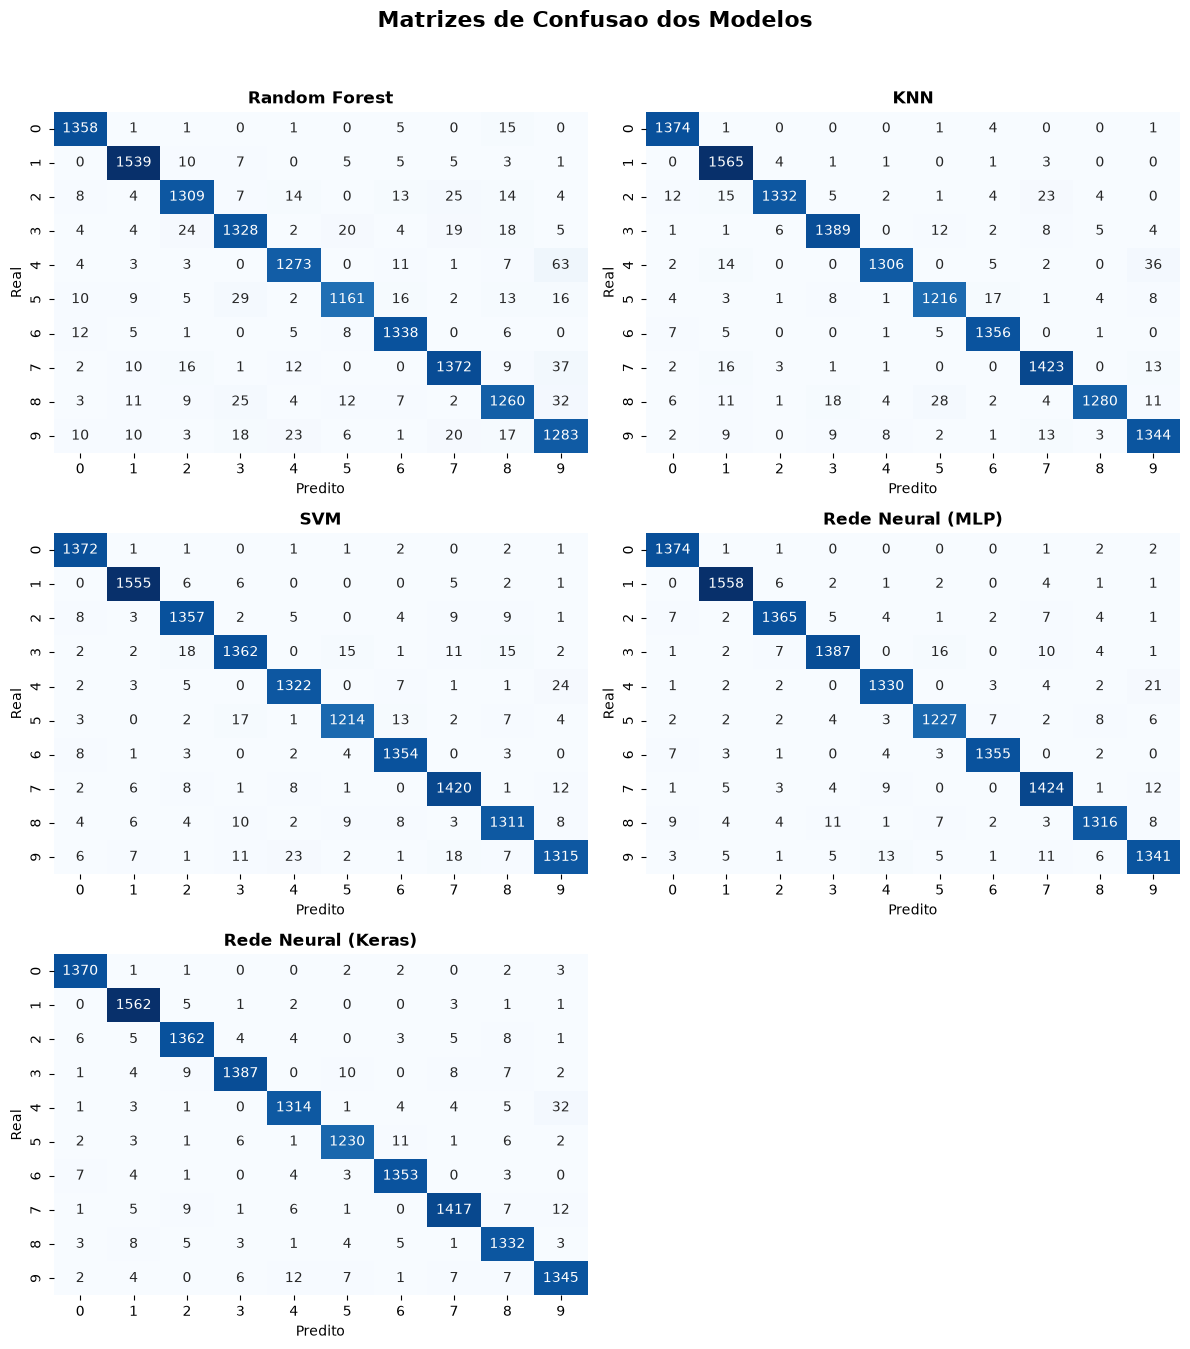

In [12]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
predicoes = [predicoes_rf, predicoes_knn, predicoes_svm, predicoes_mlp, predicoes_keras]

fig, eixos = plt.subplots(3, 2, figsize=(12, 14))
eixos_flat = eixos.ravel()

for eixo, nome, pred in zip(eixos_flat, modelos_nomes, predicoes):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=list(range(10)), yticklabels=list(range(10)), ax=eixo)
    eixo.set_title(nome, fontsize=12, fontweight='bold')
    eixo.set_xlabel('Predito')
    eixo.set_ylabel('Real')

for eixo in eixos_flat[len(modelos_nomes):]:
    eixo.axis('off')

fig.suptitle('Matrizes de Confusao dos Modelos', fontsize=16, fontweight='bold')
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(pasta_graficos / '3 = matrizes_confusao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

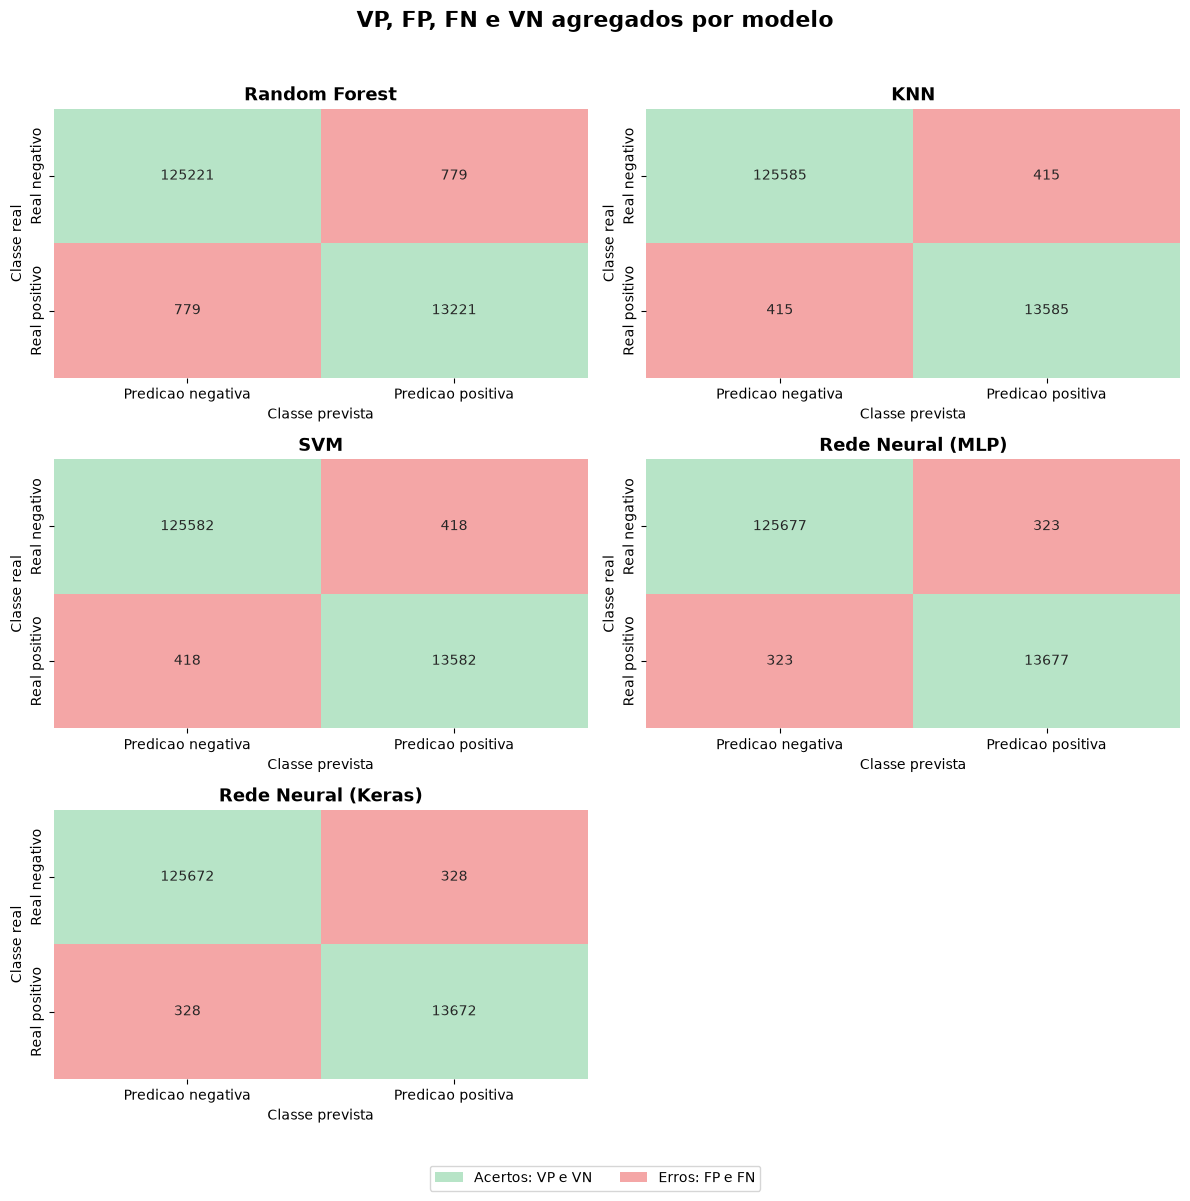

,Modelo,Verdadeiros positivos (VP),Falsos positivos (FP),Falsos negativos (FN),Verdadeiros negativos (VN)
0,Random Forest,13221,779,779,125221
1,KNN,13585,415,415,125585
2,SVM,13582,418,418,125582
3,Rede Neural (MLP),13677,323,323,125677
4,Rede Neural (Keras),13672,328,328,125672


In [13]:
resultados_tp_fp_fn_tn = []
fig, eixos = plt.subplots(3, 2, figsize=(12, 12))
eixos_flat = eixos.ravel()

for eixo, nome, pred in zip(eixos_flat, modelos_nomes, predicoes):
    matriz = confusion_matrix(y_test, pred)
    verdadeiros_positivos = falsos_positivos = falsos_negativos = verdadeiros_negativos = 0
    for indice_classe in range(len(classes)):
        verdadeiros_positivos += matriz[indice_classe, indice_classe]
        falsos_positivos += matriz[:, indice_classe].sum() - matriz[indice_classe, indice_classe]
        falsos_negativos += matriz[indice_classe, :].sum() - matriz[indice_classe, indice_classe]
        verdadeiros_negativos += (matriz.sum() - matriz[indice_classe, :].sum()
                                  - matriz[:, indice_classe].sum()
                                  + matriz[indice_classe, indice_classe])

    matriz_binaria = np.array([[verdadeiros_negativos, falsos_positivos],
                               [falsos_negativos, verdadeiros_positivos]])
    matriz_cores = np.array([[0, 1], [1, 0]])
    sns.heatmap(matriz_binaria, annot=True, fmt='d',
                cmap=ListedColormap(['#b7e4c7', '#f4a6a6']),
                norm=BoundaryNorm([-0.5, 0.5, 1.5], 2), cbar=False,
                xticklabels=['Predicao negativa', 'Predicao positiva'],
                yticklabels=['Real negativo', 'Real positivo'], ax=eixo)
    eixo.collections[-1].set_array(matriz_cores.ravel())
    eixo.set_title(nome, fontsize=13, fontweight='bold')
    eixo.set_xlabel('Classe prevista')
    eixo.set_ylabel('Classe real')
    resultados_tp_fp_fn_tn.append({'Modelo': nome,
        'Verdadeiros positivos (VP)': verdadeiros_positivos,
        'Falsos positivos (FP)': falsos_positivos,
        'Falsos negativos (FN)': falsos_negativos,
        'Verdadeiros negativos (VN)': verdadeiros_negativos})

for eixo in eixos_flat[len(modelos_nomes):]:
    eixo.axis('off')

fig.suptitle('VP, FP, FN e VN agregados por modelo', fontsize=16, fontweight='bold')
fig.legend(handles=[Patch(facecolor='#b7e4c7', label='Acertos: VP e VN'),
                    Patch(facecolor='#f4a6a6', label='Erros: FP e FN')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig(pasta_graficos / '4 = vp_fp_fn_vn_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
df_tp_fp_fn_tn = pd.DataFrame(resultados_tp_fp_fn_tn)
display(df_tp_fp_fn_tn)

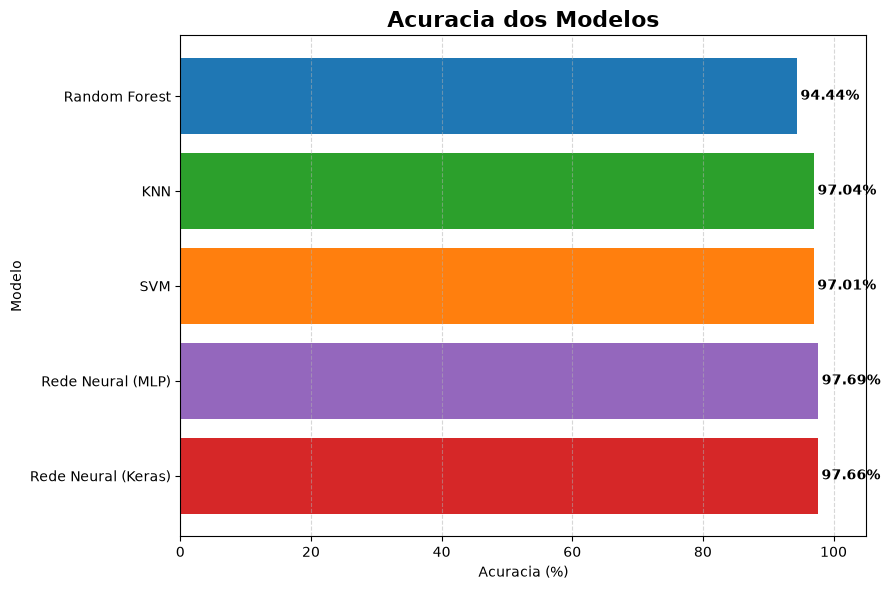

In [14]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
acuracias = [np.mean(y_test == pred) * 100 for pred in predicoes]
fig, eixo = plt.subplots(figsize=(9, 6))
barras = eixo.barh(modelos_nomes, acuracias,
                   color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728'])
eixo.set_title('Acuracia dos Modelos', fontsize=16, fontweight='bold')
eixo.set_xlabel('Acuracia (%)')
eixo.set_ylabel('Modelo')
eixo.set_xlim(0, 105)
eixo.grid(axis='x', linestyle='--', alpha=0.5)
eixo.invert_yaxis()
for barra, acuracia in zip(barras, acuracias):
    eixo.text(acuracia + 0.5, barra.get_y() + barra.get_height() / 2,
              f'{acuracia:.2f}%', va='center', fontweight='bold')
fig.tight_layout()
fig.savefig(pasta_graficos / '5 = acuracia_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

,Modelo,Tempo de treinamento (s)
0,Random Forest,29.84
1,KNN,0.21
2,SVM,331.15
3,Rede Neural (MLP),79.33
4,Rede Neural (Keras),245.26


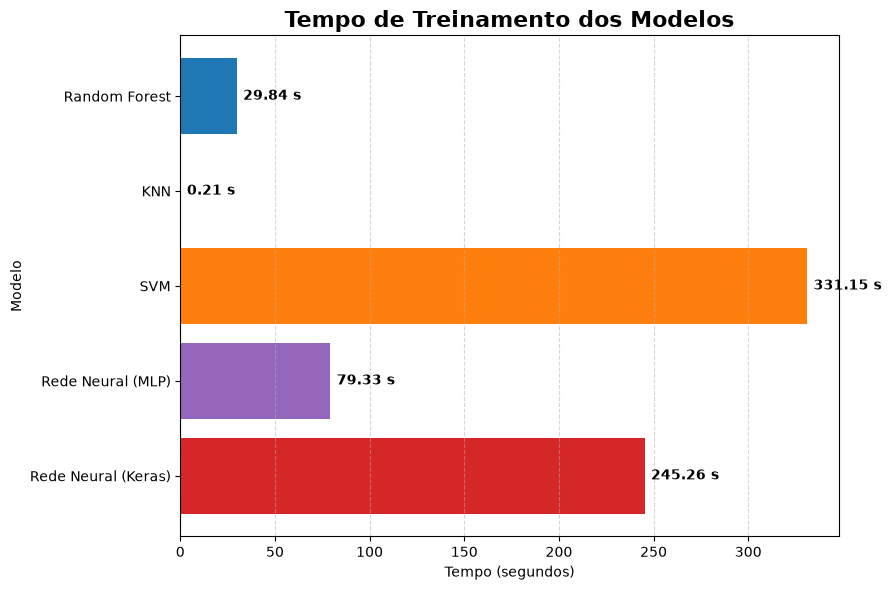

In [15]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
tempos_treinamento = [tempo_treinamento_rf, tempo_treinamento_knn,
                      tempo_treinamento_svm, tempo_treinamento_mlp, tempo_treinamento_keras]
df_tempos = pd.DataFrame({'Modelo': modelos_nomes,
                           'Tempo de treinamento (s)': tempos_treinamento})
display(df_tempos.round(2))
fig, eixo = plt.subplots(figsize=(9, 6))
barras = eixo.barh(modelos_nomes, tempos_treinamento,
                   color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728'])
eixo.set_title('Tempo de Treinamento dos Modelos', fontsize=16, fontweight='bold')
eixo.set_xlabel('Tempo (segundos)')
eixo.set_ylabel('Modelo')
eixo.grid(axis='x', linestyle='--', alpha=0.5)
eixo.invert_yaxis()
for barra, tempo in zip(barras, tempos_treinamento):
    eixo.text(tempo + max(tempos_treinamento) * 0.01,
              barra.get_y() + barra.get_height() / 2,
              f'{tempo:.2f} s', va='center', fontweight='bold')
fig.tight_layout()
fig.savefig(pasta_graficos / '6 = tempo_treinamento_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

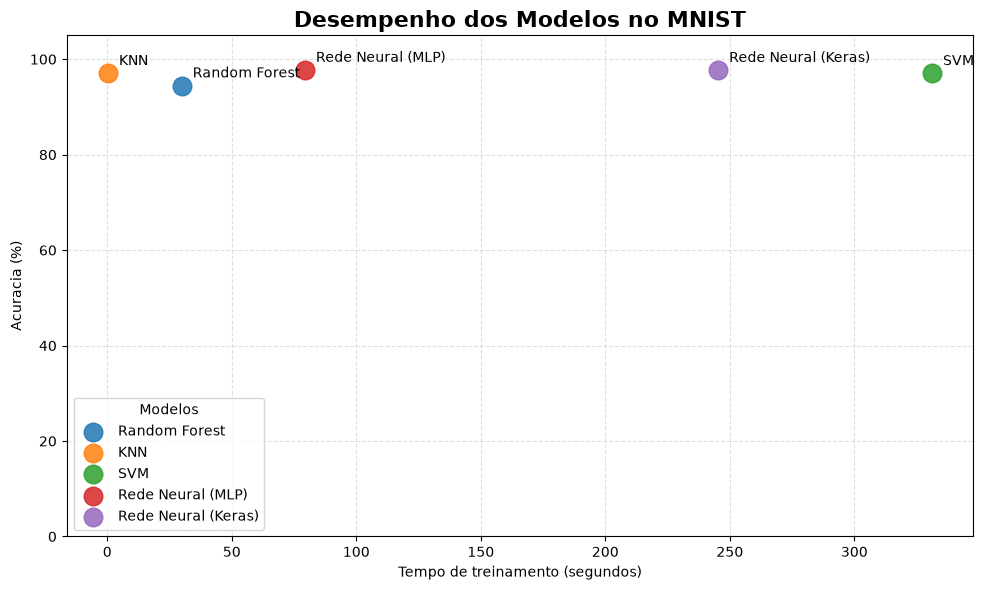

,Modelo,Acuracia (%),Tempo de treinamento (s)
3,Rede Neural (MLP),97.69,79.33
4,Rede Neural (Keras),97.66,245.26
1,KNN,97.04,0.21
2,SVM,97.01,331.15
0,Random Forest,94.44,29.84


,Modelo,Acurácia (%),Precisão ponderada,Recall ponderado,F1-score ponderado,Tempo de treinamento (s)
3,Rede Neural (MLP),97.6929,0.9769,0.9769,0.9769,79.3282
4,Rede Neural (Keras),97.6571,0.9766,0.9766,0.9766,245.2628
1,KNN,97.0357,0.9707,0.9704,0.9703,0.2142
2,SVM,97.0143,0.9701,0.9701,0.9701,331.1536
0,Random Forest,94.4357,0.9445,0.9444,0.9443,29.8398


Melhor desempenho: Rede Neural (MLP) (97.69% de acurácia).
As matrizes de confusão mostram quais pares de dígitos geram mais erros; o tempo de treinamento ajuda a avaliar o custo desse ganho de acurácia.


In [16]:
acuracias = [np.mean(y_test == pred) * 100 for pred in predicoes]
df_desempenho = pd.DataFrame({'Modelo': modelos_nomes,
                              'Acuracia (%)': acuracias,
                              'Tempo de treinamento (s)': tempos_treinamento})
fig, eixo = plt.subplots(figsize=(10, 6))
for _, linha in df_desempenho.iterrows():
    eixo.scatter(linha['Tempo de treinamento (s)'], linha['Acuracia (%)'],
                 s=180, alpha=0.85, label=linha['Modelo'])
    eixo.annotate(linha['Modelo'],
                  (linha['Tempo de treinamento (s)'], linha['Acuracia (%)']),
                  xytext=(8, 6), textcoords='offset points')
eixo.set_title('Desempenho dos Modelos no MNIST', fontsize=16, fontweight='bold')
eixo.set_xlabel('Tempo de treinamento (segundos)')
eixo.set_ylabel('Acuracia (%)')
eixo.set_ylim(0, 105)
eixo.grid(True, linestyle='--', alpha=0.4)
eixo.legend(title='Modelos')
fig.tight_layout()
fig.savefig(pasta_graficos / '7 = desempenho_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
display(df_desempenho.sort_values('Acuracia (%)', ascending=False).round(2))

# Tabela consolidada exigida para a comparação dos modelos
relatorios = [report_dict, report_dict_knn, report_dict_svm, report_dict_mlp, report_dict_keras]
modelos_treinados = [modelo_rf, modelo_knn, modelo_svm, modelo_mlp, modelo_keras]
resultados_completos = []
for nome, pred, tempo, relatorio in zip(modelos_nomes, predicoes, tempos_treinamento, relatorios):
    resultados_completos.append({
        'Modelo': nome,
        'Acurácia (%)': np.mean(y_test == pred) * 100,
        'Precisão ponderada': relatorio['weighted avg']['precision'],
        'Recall ponderado': relatorio['weighted avg']['recall'],
        'F1-score ponderado': relatorio['weighted avg']['f1-score'],
        'Tempo de treinamento (s)': tempo
    })

df_resultados_completos = pd.DataFrame(resultados_completos)
display(df_resultados_completos.sort_values('Acurácia (%)', ascending=False).round(4))

melhor_indice = int(np.argmax(acuracias))
melhor_modelo = modelos_treinados[melhor_indice]
melhor_nome = modelos_nomes[melhor_indice]
print(f'Melhor desempenho: {melhor_nome} ({acuracias[melhor_indice]:.2f}% de acurácia).')
print('As matrizes de confusão mostram quais pares de dígitos geram mais erros; o tempo de treinamento ajuda a avaliar o custo desse ganho de acurácia.')

Fase 5: Robustez do Modelo e Predição com Imagens Próprias

Nesta fase, testamos situações mais próximas do mundo real. Primeiro, retiramos alguns dígitos do treinamento para observar como o modelo reage a algo que nunca viu. Depois, testamos uma imagem manuscrita própria, preparando-a para ficar parecida com as imagens do MNIST: em tons de cinza, centralizada, com tamanho 28 × 28 e valores normalizados entre 0 e 1.

Fase 5.1 - Treinamento com Classes Ocultas

In [17]:
# Usa a divisão estratificada e os dados normalizados criados na Fase 2.
classes_ocultas = np.array([4, 7])
mascara_treino = ~np.isin(y_train, classes_ocultas)
X_train_restrito = X_train[mascara_treino]
y_train_restrito = y_train[mascara_treino]

print("[Fase 5.1] Treinando sem os dígitos 4 e 7...")
print(f"Classes presentes no treino: {np.unique(y_train_restrito)}")

modelo_restrito = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
modelo_restrito.fit(X_train_restrito, y_train_restrito)
print("Modelo restrito treinado com sucesso.")

[Fase 5.1] Treinando sem os dígitos 4 e 7...
Classes presentes no treino: [0 1 2 3 5 6 8 9]
Modelo restrito treinado com sucesso.


Fase 5.2 - Comportamento diante de Classes NÃO Vistas

In [18]:
if 'modelo_restrito' not in globals():
    raise RuntimeError("Execute a célula da Fase 5.1 antes desta.")

# Código de predição OOD: use somente as imagens das classes ocultas.
mascara_teste_ood = np.isin(y_test, classes_ocultas)
X_test_ood = X_test[mascara_teste_ood]
y_test_ood = y_test[mascara_teste_ood]
predicoes_ood = modelo_restrito.predict(X_test_ood)

classes_conhecidas, contagens = np.unique(predicoes_ood, return_counts=True)
print(f"Amostras OOD avaliadas: {len(y_test_ood)}")
print("Classes previstas pelo modelo:", classes_conhecidas)


Amostras OOD avaliadas: 2824
Classes previstas pelo modelo: [0 1 2 3 5 6 8 9]


#### Como interpretar as predições das classes ocultas

Os dígitos 4 e 7 foram retirados do treinamento. Portanto, o classificador não possui essas duas opções e é obrigado a atribuir cada imagem a uma das classes que conhece. O gráfico abaixo resume para quais classes conhecidas essas imagens foram direcionadas; não representa acertos de 4 ou 7.

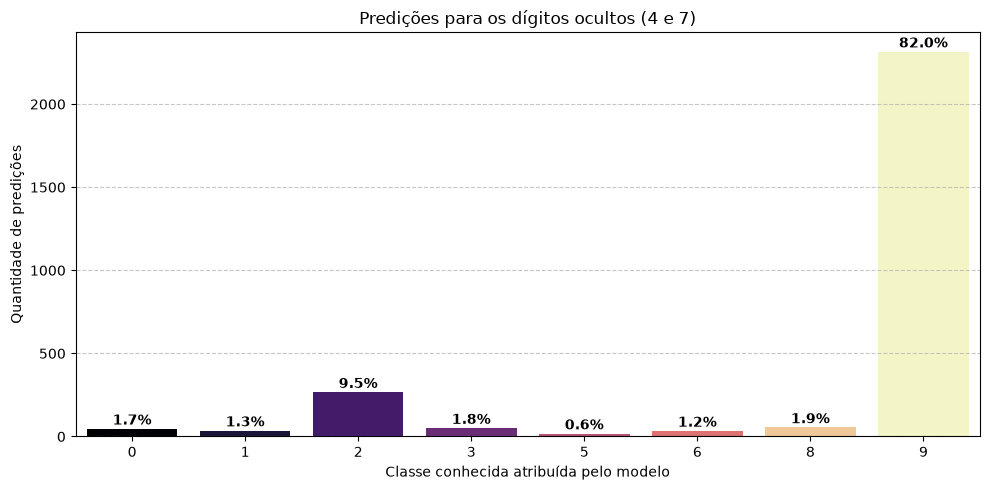

In [19]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=classes_conhecidas, y=contagens, hue=classes_conhecidas,
                palette="magma", legend=False)

porcentagens = (contagens / contagens.sum()) * 100
for barra, porcentagem in zip(ax.patches, porcentagens):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 5,
        f'{porcentagem:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title("Predições para os dígitos ocultos (4 e 7)")
plt.xlabel("Classe conhecida atribuída pelo modelo")
plt.ylabel("Quantidade de predições")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(pasta_graficos / '8 = predicoes_classes_ocultas.png', dpi=300, bbox_inches='tight')
plt.show()


#### Matriz de confusão OOD

Nesta matriz, as linhas são as classes reais e as colunas são as classes previstas. Apenas as linhas 4 e 7 terão valores, pois o conjunto OOD contém somente esses dígitos. Como 4 e 7 não existem no treinamento, suas colunas ficam zeradas: a matriz evidencia a "falsa certeza" de um classificador fechado, que sempre escolhe alguma classe conhecida.

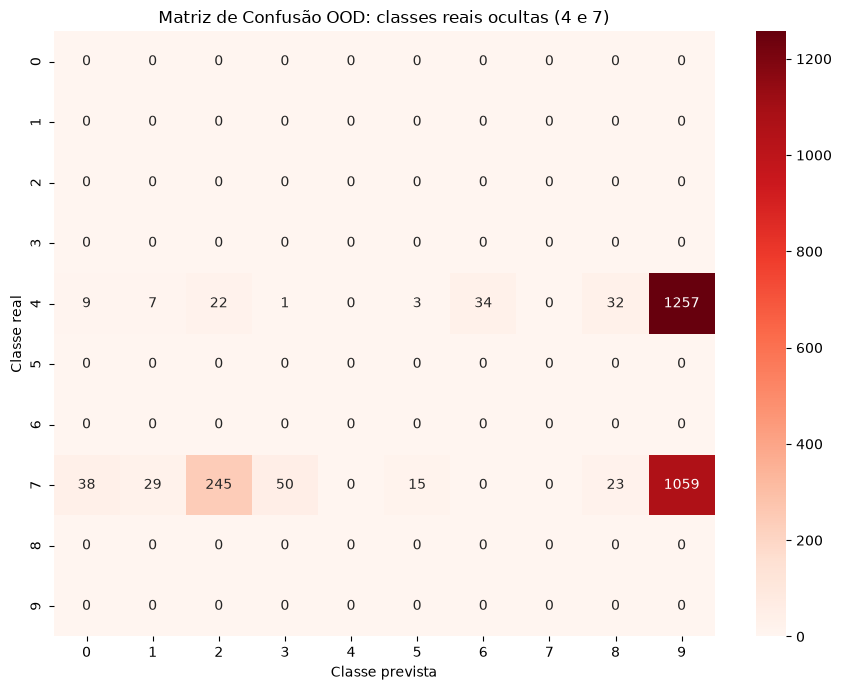

In [20]:
# Gráfico separado: matriz de confusão exclusiva do cenário OOD.
rotulos_ood = list(range(10))
matriz_ood = confusion_matrix(y_test_ood, predicoes_ood, labels=rotulos_ood)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=rotulos_ood, yticklabels=rotulos_ood)
plt.title('Matriz de Confusão OOD: classes reais ocultas (4 e 7)')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.tight_layout()
plt.savefig(pasta_graficos / '9 = matriz_confusao_ood.png', dpi=300, bbox_inches='tight')
plt.show()


Fase 5.3 - Predição com Imagem Manuscrita Própria

In [114]:
# ============================================================
# ESCOLHA DO MODELO PARA TESTAR
# ============================================================

modelos = {
    "Random Forest": modelo_rf,
    "KNN": modelo_knn,
    "SVM": modelo_svm,
    "MLPClassifier": modelo_mlp,
    "Keras": modelo_keras
}

print("Modelos disponíveis:")
for nome in modelos:
    print(f"- {nome}")

nome_modelo_escolhido = input(
    "\nDigite o nome do modelo que deseja testar: "
)

if nome_modelo_escolhido not in modelos:
    raise ValueError(
        f"Modelo inválido. Escolha entre: {list(modelos.keys())}"
    )

modelo_selecionado = modelos[nome_modelo_escolhido]

print(f"\nModelo selecionado: {nome_modelo_escolhido}")

Modelos disponíveis:
- Random Forest
- KNN
- SVM
- MLPClassifier
- Keras

Modelo selecionado: MLPClassifier


In [115]:
# Escolha a imagem que deseja testar alterando somente este nome
nome_imagem = "Imagem 11.png"  # ex.: "Imagem 2.png", "Imagem 7.png"

pasta_imagens = Path.cwd() / "imagem"
arquivos_imagem = sorted(
    list(pasta_imagens.glob("*.png")) + list(pasta_imagens.glob("*.jpg")) + list(pasta_imagens.glob("*.jpeg"))
)

if not arquivos_imagem:
    raise FileNotFoundError(
        f"Nenhuma imagem .png, .jpg ou .jpeg encontrada em: {pasta_imagens}"
    )

caminho_imagem = pasta_imagens / nome_imagem
if not caminho_imagem.exists():
    imagens_disponiveis = [img.name for img in arquivos_imagem]
    raise FileNotFoundError(
        f"Imagem '{nome_imagem}' nÃ£o foi encontrada em {pasta_imagens}. "
        f"Imagens disponÃ­veis: {imagens_disponiveis}"
    )

print(f"Imagem encontrada e selecionada: {caminho_imagem.name}")

Imagem encontrada e selecionada: Imagem 11.png


In [116]:
def preprocessar_imagem(caminho_imagem, inverter_cores=False, tamanho=(28, 28)):
    imagem = cv2.imread(str(caminho_imagem), cv2.IMREAD_GRAYSCALE)

    if imagem is None:
        raise FileNotFoundError(f"Não foi possível ler a imagem: {caminho_imagem}")

    # Não inverta duas vezes
    if inverter_cores:
        imagem = cv2.bitwise_not(imagem)

    mascara = imagem > 10
    if not np.any(mascara):
        parcela = imagem
    else:
        ys, xs = np.where(mascara)
        y_min, y_max = ys.min(), ys.max()
        x_min, x_max = xs.min(), xs.max()
        parcela = imagem[y_min:y_max + 1, x_min:x_max + 1]

    altura, largura = parcela.shape
    if altura == 0 or largura == 0:
        altura, largura = 28, 28

    escala = 20.0 / max(altura, largura)
    nova_altura = max(1, int(round(altura * escala)))
    nova_largura = max(1, int(round(largura * escala)))
    parcela_redimensionada = cv2.resize(
        parcela, (nova_largura, nova_altura), interpolation=cv2.INTER_AREA
    )

    canvas = np.full((tamanho[0], tamanho[1]), 255, dtype=np.uint8)
    y_offset = (tamanho[0] - nova_altura) // 2
    x_offset = (tamanho[1] - nova_largura) // 2
    canvas[y_offset:y_offset + nova_altura, x_offset:x_offset + nova_largura] = parcela_redimensionada

    # Mantém o padrão MNIST correto
    imagem_final = canvas.astype(np.float32) / 255.0

    return imagem_final

In [117]:
# ============================================================
# EXECUTAR PREVISÃO
# ============================================================


# Prepara a imagem
img_pronta = preprocessar_imagem(
    caminho_imagem, 
    inverter_cores=False)


# Todos os modelos foram treinados com 784 pixels
entrada_modelo = img_pronta.reshape(1, 784)

# ============================================================
# PREVISÃO
# ============================================================

if nome_modelo_escolhido == "Keras":

    # Keras retorna 10 probabilidades
    probabilidades = modelo_selecionado.predict(
        entrada_modelo,
        verbose=0
    )[0]

    predicao = int(np.argmax(probabilidades))

    titulo_saida = "Probabilidades de saída (Keras)"

else:

    # Modelos Scikit-Learn
    predicao = int(
        modelo_selecionado.predict(entrada_modelo)[0]
    )

    probabilidades = None
    titulo_saida = "Previsão de classe"

    # RF, KNN e MLPClassifier
    if hasattr(modelo_selecionado, "predict_proba"):

        probabilidades = modelo_selecionado.predict_proba(
            entrada_modelo
        )[0]

        titulo_saida = "Probabilidades de saída"

    # SVM
    elif hasattr(modelo_selecionado, "decision_function"):

        escores = modelo_selecionado.decision_function(
            entrada_modelo
        )

        if escores.ndim == 2:
            escores = escores[0]

        probabilidades = np.exp(
            escores - np.max(escores)
        )

        probabilidades /= probabilidades.sum()

        titulo_saida = (
            "Escores normalizados "
            "(SVM sem calibração)"
        )

# ============================================================
# RESULTADO
# ============================================================

print("=" * 50)
print(f"MODELO: {nome_modelo_escolhido}")
print(f"DÍGITO PREVISTO: {predicao}")
print("=" * 50)

if probabilidades is not None:

    print(f"\n{titulo_saida}:")

    for digito, probabilidade in enumerate(probabilidades):

        print(
            f"Dígito {digito}: "
            f"{probabilidade:.2%}"
        )

MODELO: MLPClassifier
DÍGITO PREVISTO: 5

Probabilidades de saída:
Dígito 0: 0.00%
Dígito 1: 0.00%
Dígito 2: 0.00%
Dígito 3: 0.00%
Dígito 4: 0.00%
Dígito 5: 100.00%
Dígito 6: 0.00%
Dígito 7: 0.00%
Dígito 8: 0.00%
Dígito 9: 0.00%


#### Resultado da predição da imagem própria

À esquerda está a imagem depois do pré-processamento para o padrão MNIST (28 × 28 pixels). À direita aparecem as probabilidades do modelo; quando o melhor modelo for o SVM no perfil local, o gráfico mostra escores normalizados, pois as probabilidades calibradas foram desativadas para acelerar o treino.

Modelo: MLPClassifier
Dígito real: 5
Dígito previsto: 5
Resultado: ACERTOU!


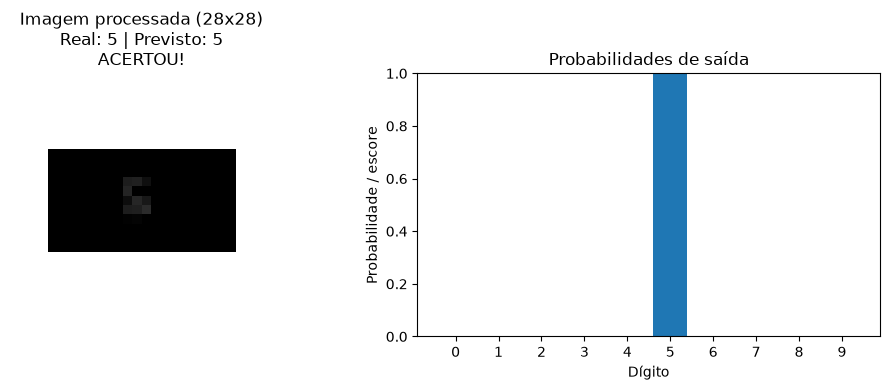

In [118]:
# ============================================================
# RESULTADO: ACERTO OU ERRO
# ============================================================

# Informe o dígito verdadeiro da imagem
digito_real = 5

# Compara a previsão com o valor verdadeiro
acertou = predicao == digito_real

if acertou:
    resultado = "ACERTOU!"
else:
    resultado = "ERROU!"

print("=" * 50)
print(f"Modelo: {nome_modelo_escolhido}")
print(f"Dígito real: {digito_real}")
print(f"Dígito previsto: {predicao}")
print(f"Resultado: {resultado}")
print("=" * 50)


# ============================================================
# GRÁFICO
# ============================================================

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))

# ------------------------------------------------------------
# Imagem processada
# ------------------------------------------------------------

eixos[0].imshow(img_pronta, cmap='gray')

eixos[0].set_title(
    f"Imagem processada (28x28)\n"
    f"Real: {digito_real} | Previsto: {predicao}\n"
    f"{resultado}"
)

eixos[0].axis('off')


# ------------------------------------------------------------
# Probabilidades
# ------------------------------------------------------------

eixos[1].bar(
    range(10),
    probabilidades
)

eixos[1].set_title(titulo_saida)
eixos[1].set_xlabel('Dígito')
eixos[1].set_ylabel('Probabilidade / escore')
eixos[1].set_xticks(range(10))
eixos[1].set_ylim(0, 1)

plt.tight_layout()

plt.savefig(
    pasta_graficos / '10_predicao_imagem_propria.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()